In [12]:
# !nvidia-smi

In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# %load_ext cudf.pandas
# %load_ext cuml.accel

In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
path = '/kaggle/input/competitions/playground-series-s6e3/'
path = './data/'
train_data = pd.read_csv(path + 'train.csv')
test_data = pd.read_csv(path + 'test.csv')


In [17]:
train_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [18]:
with pd.option_context('display.max_columns', None):
    display(train_data)
# Settings return to normal once you exit this block

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [19]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [20]:
train_data.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

In [21]:
train_data.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [22]:
train_data.duplicated().sum()

np.int64(0)

In [23]:
train_data.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges']
       

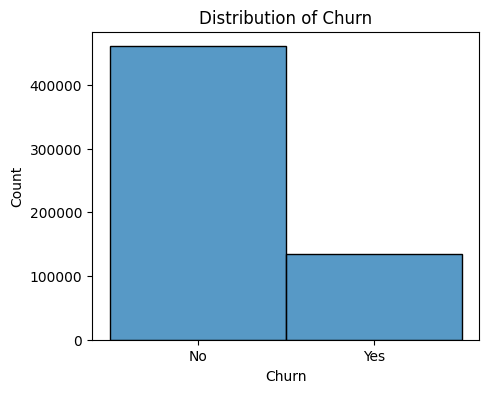

In [25]:
plt.figure(figsize=(5, 4))
sns.histplot(data=train_data, x='Churn')
plt.title('Distribution of Churn')
plt.show()

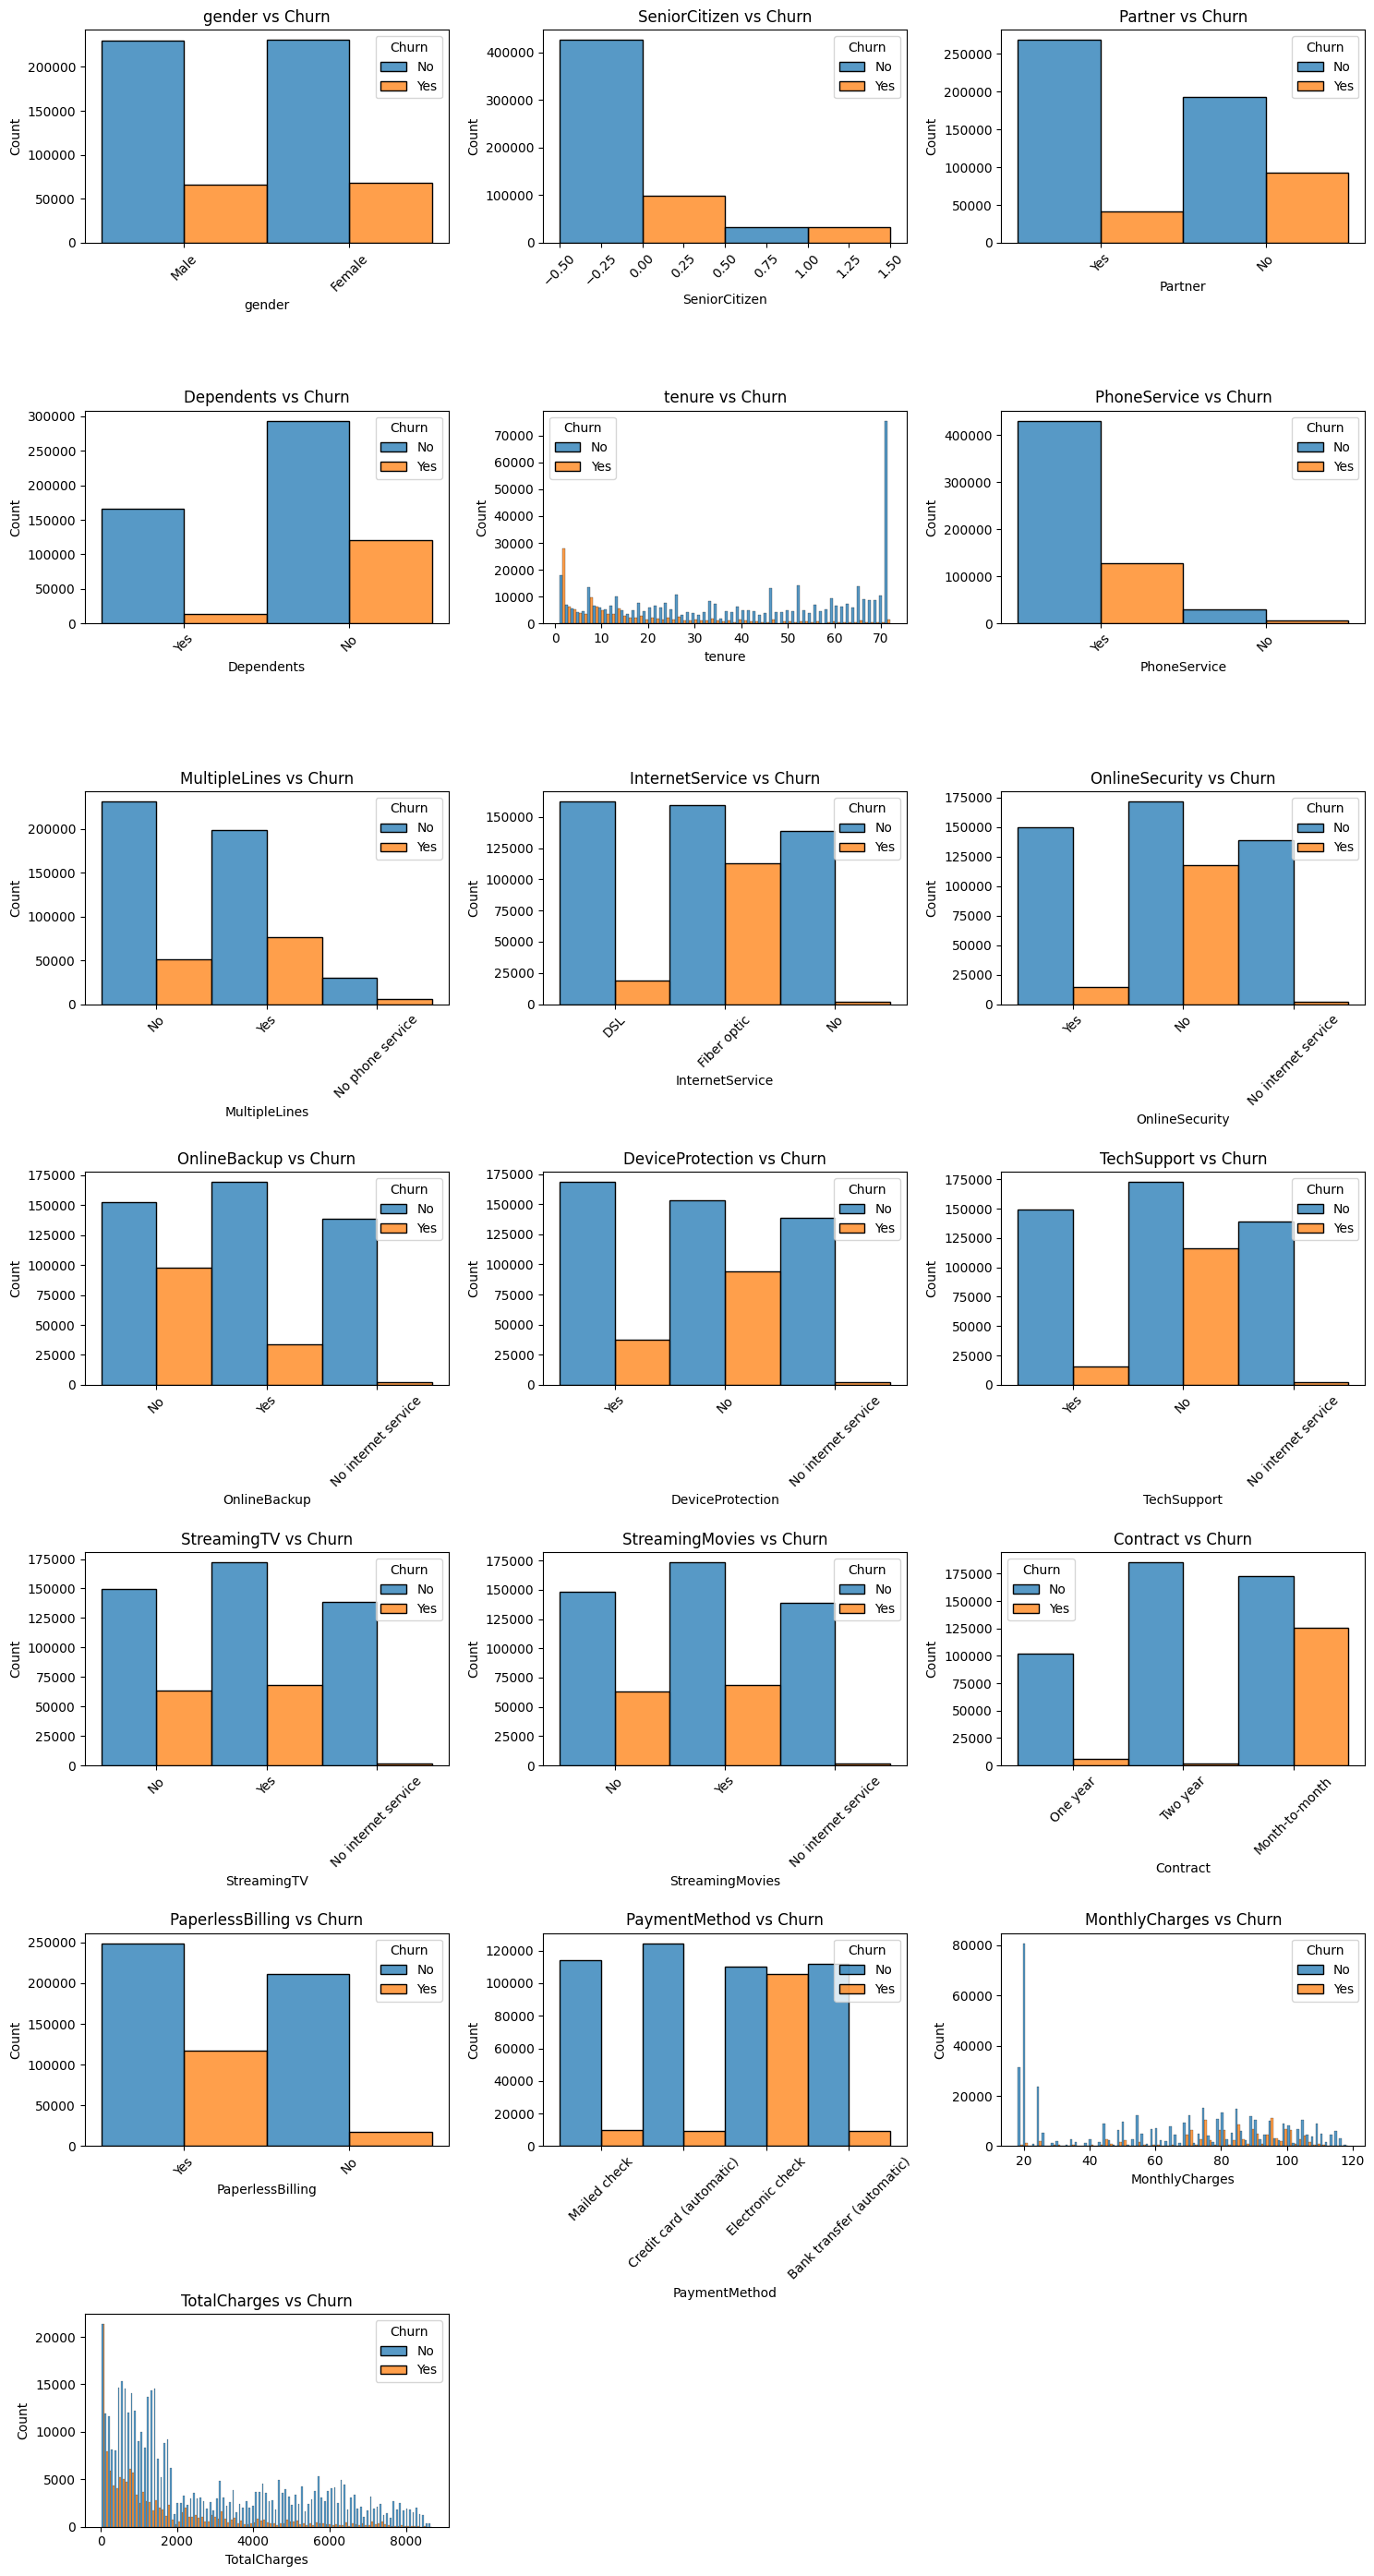

In [26]:
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    is_discrete = train_data[feature].dtype == 'object' or train_data[feature].nunique() < 10
    sns.histplot(
        data=train_data, x=feature, hue='Churn',
        multiple='dodge', discrete=is_discrete, ax=axes[i],
    )
    axes[i].set_title(f'{feature} vs Churn')
    if is_discrete:
        axes[i].tick_params(axis='x', rotation=45)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

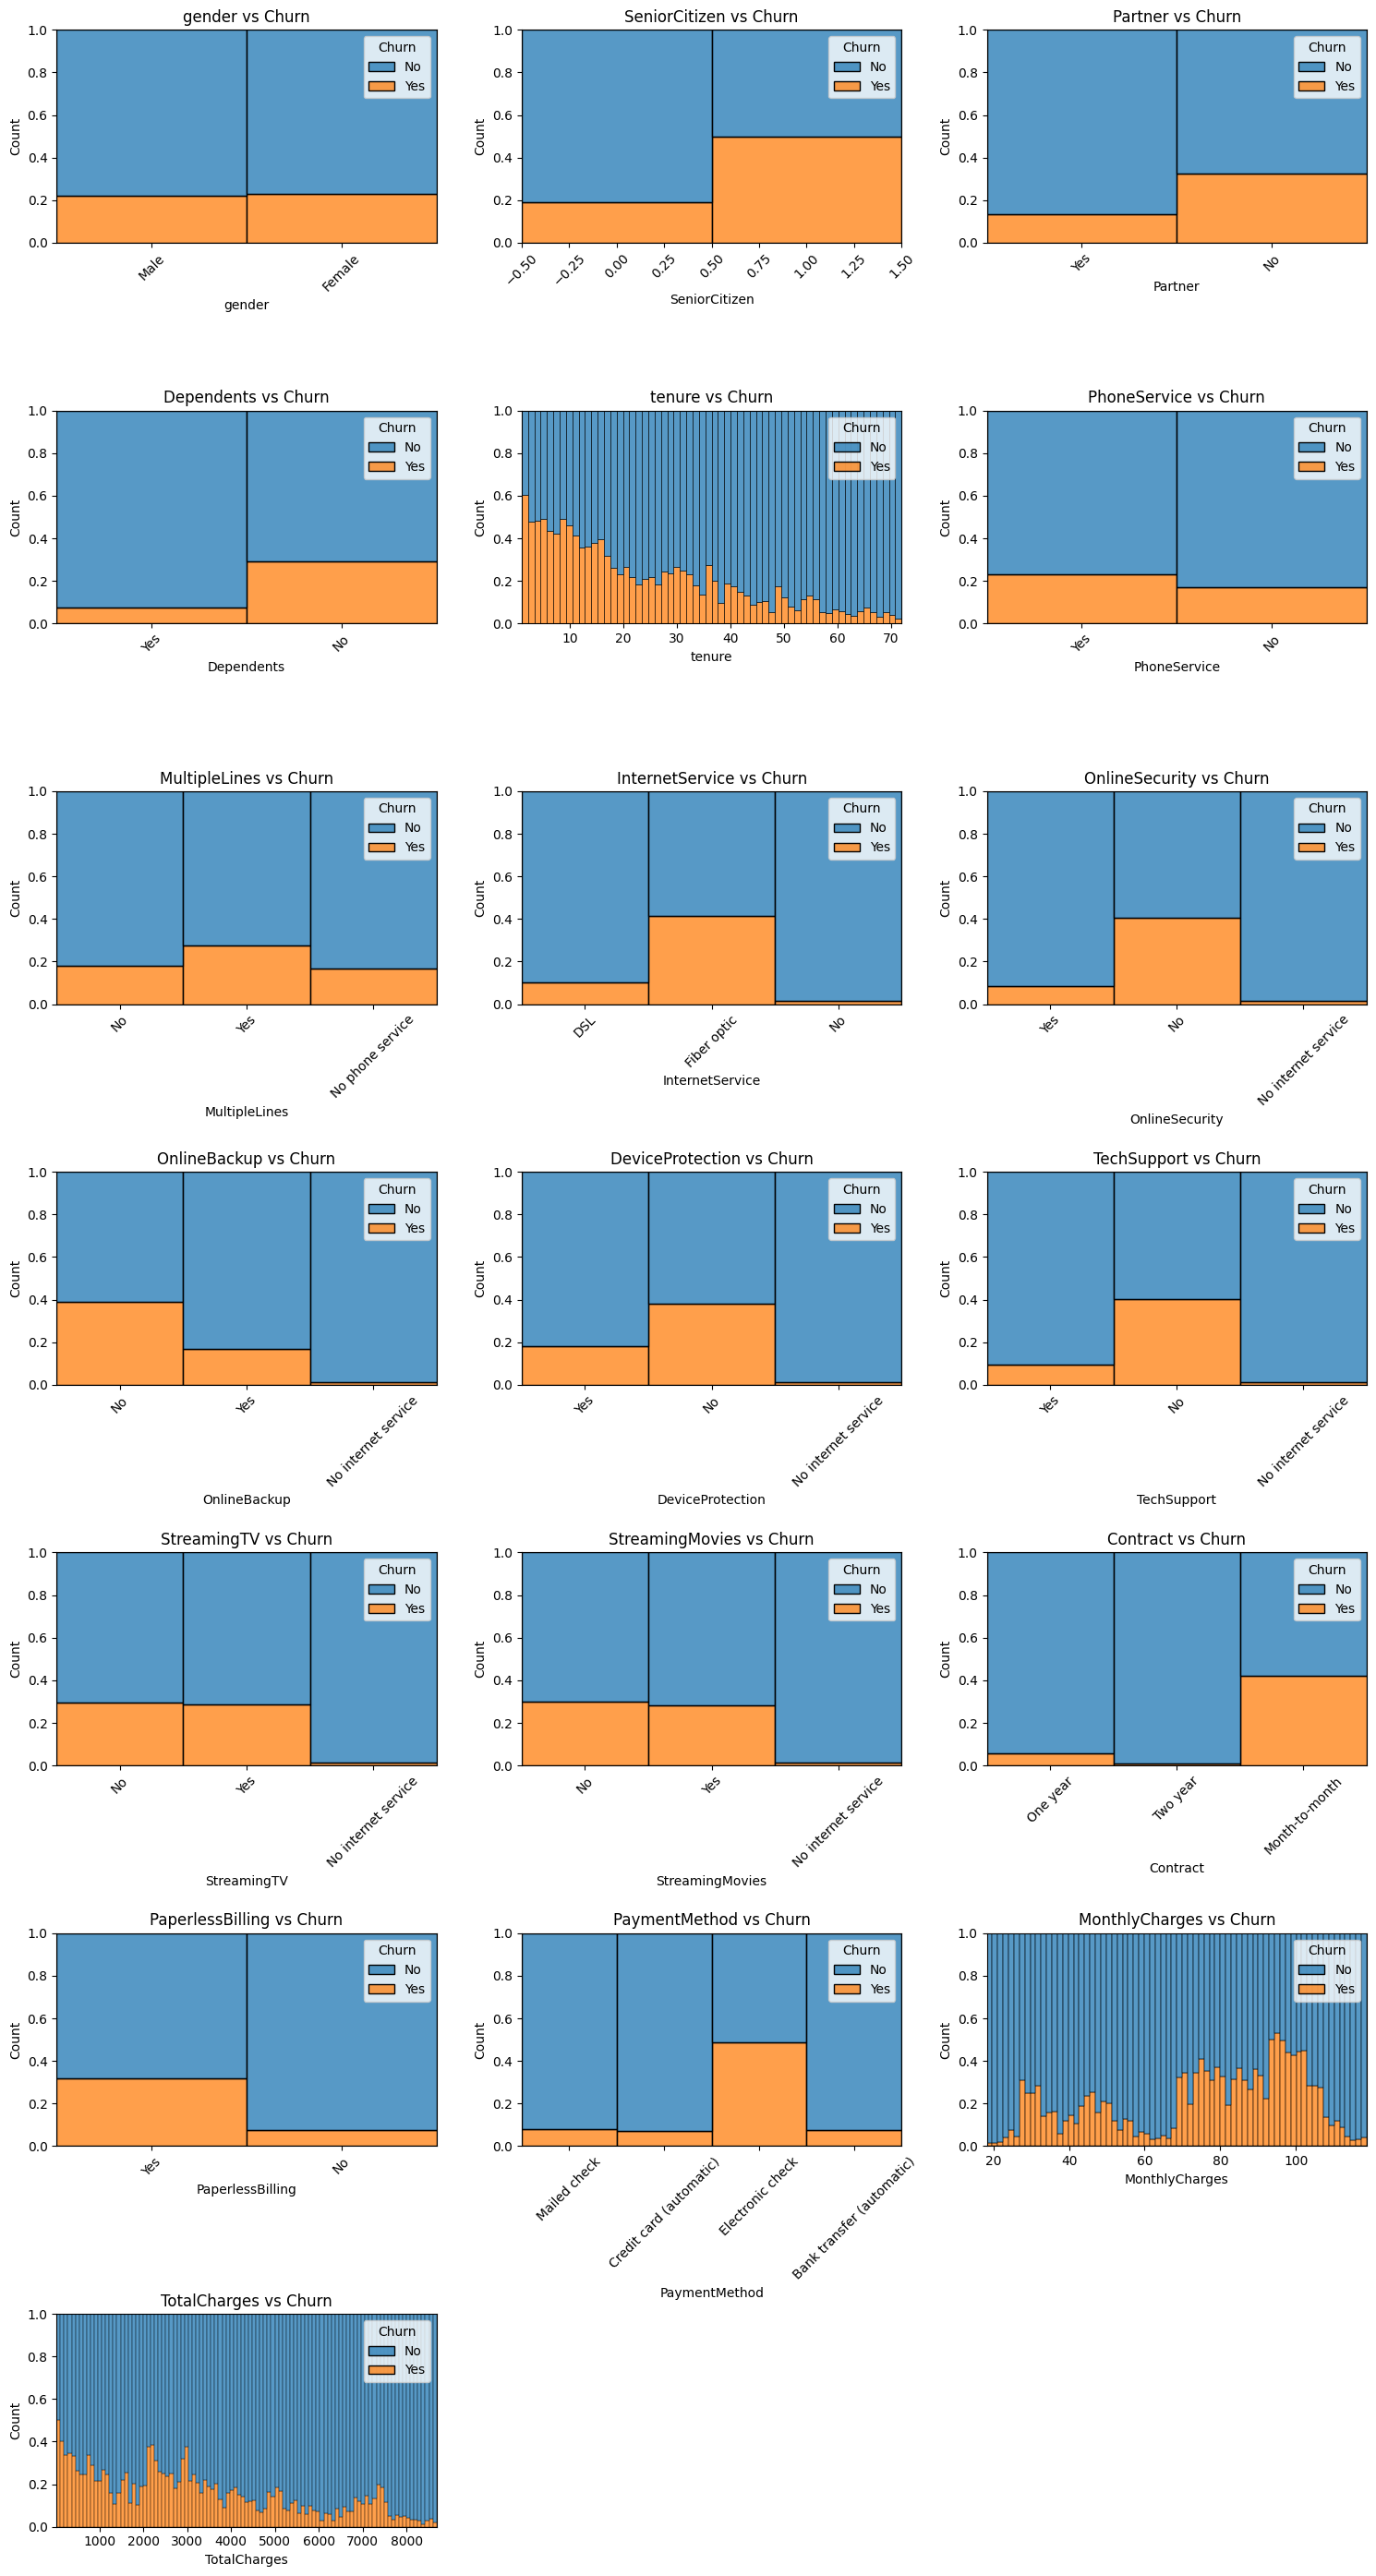

In [27]:
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    is_discrete = train_data[feature].dtype == 'object' or train_data[feature].nunique() < 10
    sns.histplot(
        data=train_data, x=feature, hue='Churn',
        multiple='fill', discrete=is_discrete, ax=axes[i],
    )
    axes[i].set_title(f'{feature} vs Churn')
    if is_discrete:
        axes[i].tick_params(axis='x', rotation=45)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## EDA for test_data

In [28]:
test_data

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25


In [29]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  str    
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  str    
 4   Dependents        254655 non-null  str    
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  str    
 7   MultipleLines     254655 non-null  str    
 8   InternetService   254655 non-null  str    
 9   OnlineSecurity    254655 non-null  str    
 10  OnlineBackup      254655 non-null  str    
 11  DeviceProtection  254655 non-null  str    
 12  TechSupport       254655 non-null  str    
 13  StreamingTV       254655 non-null  str    
 14  StreamingMovies   254655 non-null  str    
 15  Contract          254655 non-null  str    
 16  PaperlessBilling  254655 non-nu

In [30]:
test_data.nunique()

id                  254655
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1875
TotalCharges         24995
dtype: int64

In [31]:
test_data.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


In [32]:
test_data.duplicated().sum()

np.int64(0)

In [33]:
test_data.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [34]:
test_features = [c for c in features if c in test_data.columns]

In [35]:
if 'Churn' in test_data.columns:
    plt.figure(figsize=(5, 4))
    sns.histplot(data=test_data, x='Churn')
    plt.title('Distribution of Churn (test)')
    plt.show()
else:
    print("'Churn' column not present in test_data.")

'Churn' column not present in test_data.


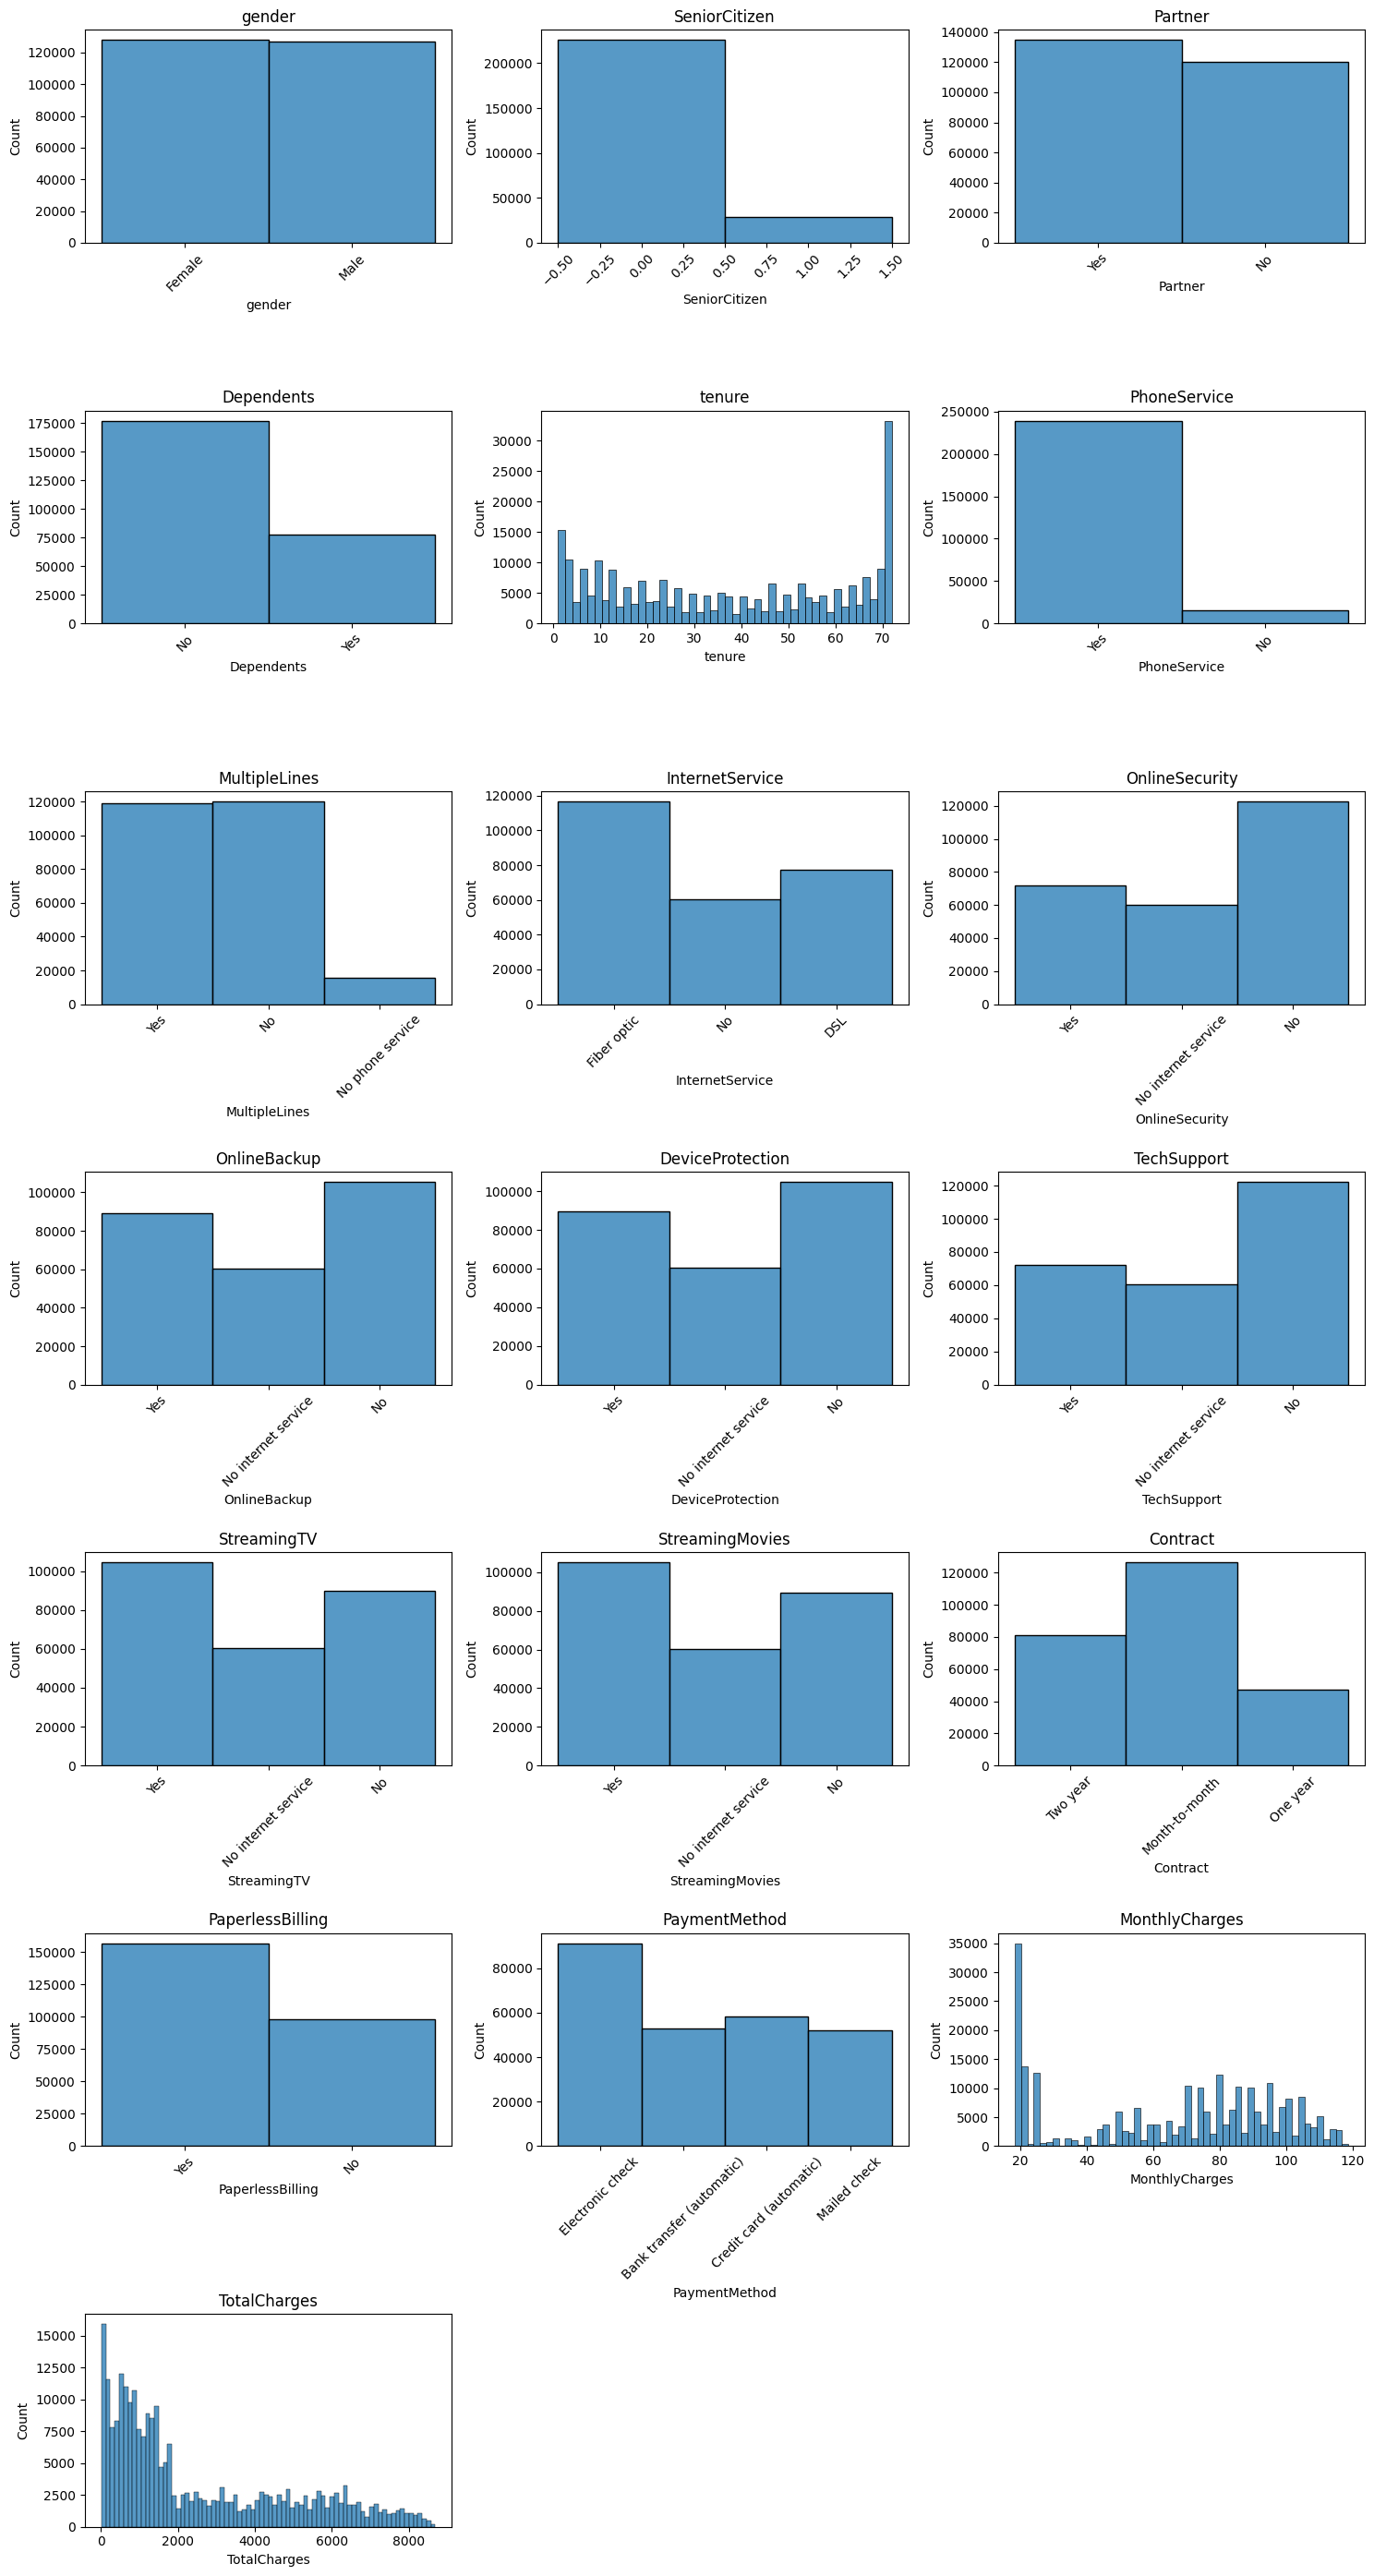

In [36]:
n_features = len(test_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

hue = 'Churn' if 'Churn' in test_data.columns else None

for i, feature in enumerate(test_features):
    is_discrete = test_data[feature].dtype == 'object' or test_data[feature].nunique() < 10
    sns.histplot(
        data=test_data, x=feature, hue=hue,
        multiple='dodge', discrete=is_discrete, ax=axes[i],
    )
    axes[i].set_title(f'{feature} vs Churn (test)' if hue else feature)
    if is_discrete:
        axes[i].tick_params(axis='x', rotation=45)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

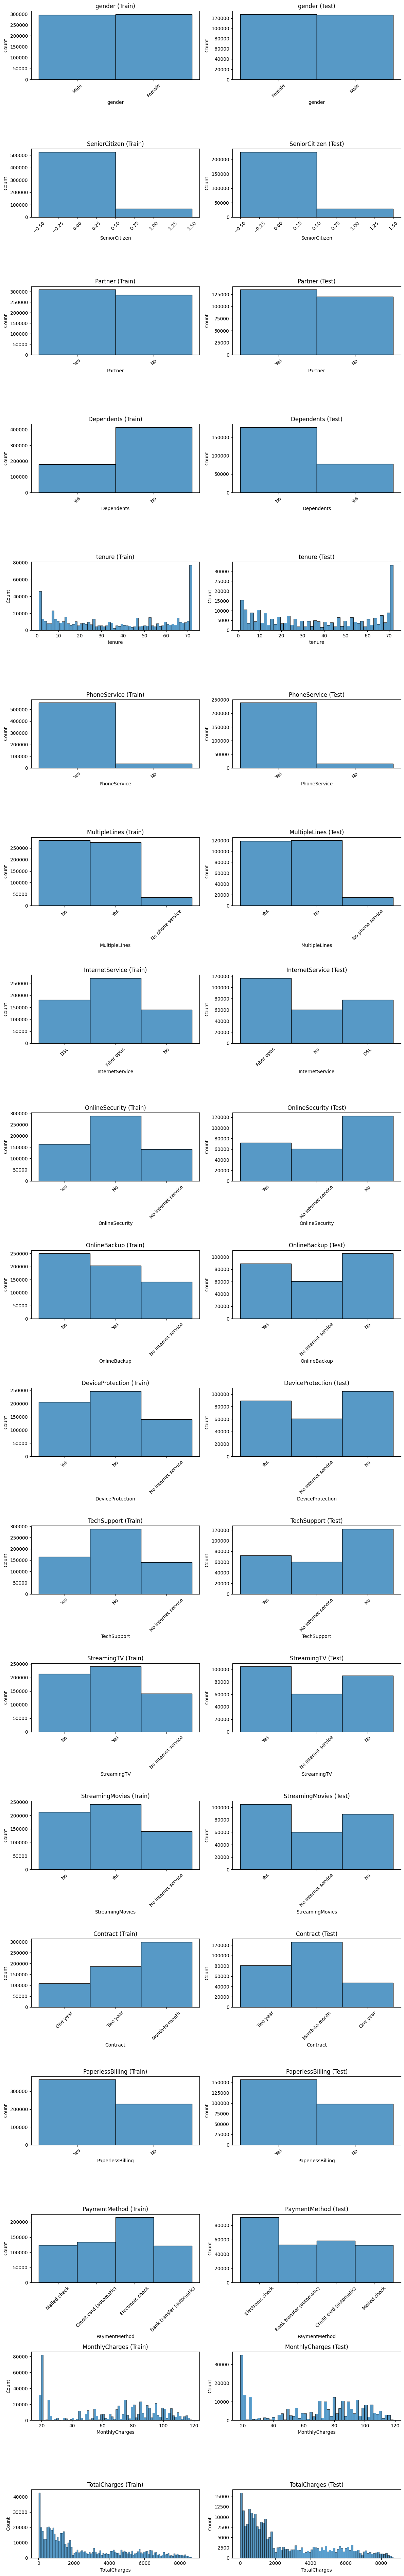

In [37]:
fig, axes = plt.subplots(len(features), 2, figsize=(12, 4 * len(features)))

for i, feature in enumerate(test_features):
    for ax, (data, label) in zip(axes[i], [(train_data, 'Train'), (test_data, 'Test')]):
        is_discrete = data[feature].dtype == 'object' or data[feature].nunique() < 10
        sns.histplot(data=data, x=feature, discrete=is_discrete, ax=ax)
        ax.set_title(f'{feature} ({label})')
        if is_discrete:
            ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [38]:
from scipy import stats

rows = []
for feature in features:
    is_discrete = train_data[feature].dtype == 'object' or train_data[feature].nunique() < 10

    if is_discrete:
        train_counts = train_data[feature].value_counts()
        test_counts  = test_data[feature].value_counts()
        all_cats = train_counts.index.union(test_counts.index)
        contingency = pd.DataFrame({
            'train': train_counts.reindex(all_cats, fill_value=0),
            'test':  test_counts.reindex(all_cats, fill_value=0),
        })
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        rows.append({'feature': feature, 'test': 'Chi-Square', 'statistic': chi2, 'p_value': p})
    else:
        stat, p = stats.ks_2samp(train_data[feature], test_data[feature])
        rows.append({'feature': feature, 'test': 'KS', 'statistic': stat, 'p_value': p})

dist_test_df = pd.DataFrame(rows)
dist_test_df['distribution_shift'] = dist_test_df['p_value'] < 0.05
display(dist_test_df.style
        .format({'statistic': '{:.4f}', 'p_value': '{:.4e}'})
        .map(lambda v: 'color: red' if v else '', subset=['distribution_shift']))

,feature,test,statistic,p_value,distribution_shift
0,gender,Chi-Square,0.0994,7.5257e-01,False
1,SeniorCitizen,Chi-Square,0.4055,5.2425e-01,False
2,Partner,Chi-Square,45.6812,1.3915e-11,True
3,Dependents,Chi-Square,4.1864,4.0750e-02,True
4,tenure,KS,0.0171,1.5501e-45,True
5,PhoneService,Chi-Square,0.2691,6.0394e-01,False
6,MultipleLines,Chi-Square,18.1883,1.1232e-04,True
7,InternetService,Chi-Square,0.0005,9.9974e-01,False
8,OnlineSecurity,Chi-Square,29.0948,4.8101e-07,True
9,OnlineBackup,Chi-Square,45.9021,1.0777e-10,True


## Adversarial Validation

Train a classifier to distinguish train rows from test rows. An OOF accuracy meaningfully above the majority-class baseline (~70% here, since train/test ≈ 594k/255k ≈ 70/30) signals joint-distribution drift beyond what the univariate tests above can detect.

In [39]:
combined = pd.concat([
    train_data[features].assign(is_train=1),
    test_data[features].assign(is_train=0),
], ignore_index=True)

cat_cols = [c for c in features if pd.api.types.is_string_dtype(combined[c])]
for c in cat_cols:
    combined[c] = combined[c].astype('category').cat.codes

combined

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,is_train
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10,1653.85,1
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50,3778.20,1
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40,5841.35,1
3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70,70.70,1
4,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848844,1,0,1,1,72,1,0,2,1,1,1,1,1,1,2,0,1,19.95,1443.65,0
848845,1,1,1,0,16,1,2,1,0,0,0,2,2,2,0,1,2,100.15,1563.50,0
848846,1,0,1,0,35,1,2,1,2,0,2,2,2,2,0,1,0,105.80,3132.75,0
848847,0,0,0,0,25,1,0,2,1,1,1,1,1,1,2,1,1,20.25,511.25,0


In [40]:
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 848849 entries, 0 to 848848
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            848849 non-null  int8   
 1   SeniorCitizen     848849 non-null  int64  
 2   Partner           848849 non-null  int8   
 3   Dependents        848849 non-null  int8   
 4   tenure            848849 non-null  int64  
 5   PhoneService      848849 non-null  int8   
 6   MultipleLines     848849 non-null  int8   
 7   InternetService   848849 non-null  int8   
 8   OnlineSecurity    848849 non-null  int8   
 9   OnlineBackup      848849 non-null  int8   
 10  DeviceProtection  848849 non-null  int8   
 11  TechSupport       848849 non-null  int8   
 12  StreamingTV       848849 non-null  int8   
 13  StreamingMovies   848849 non-null  int8   
 14  Contract          848849 non-null  int8   
 15  PaperlessBilling  848849 non-null  int8   
 16  PaymentMethod     848849 non-nu

### Cross-validation: `StratifiedKFold`

- The `is_train` target is imbalanced (~70/30). `StratifiedKFold` preserves this ratio in every fold, giving more stable per-fold estimates and a less noisy OOF accuracy.
- Plain `KFold` works but doesn't guarantee balanced folds — with shuffling and enough data the ratios will be close, but not identical.
- `GroupKFold` / `StratifiedGroupKFold`: no natural group variable (ids are row-level).
- `TimeSeriesSplit`: no time ordering to preserve — `id` is sequential but carries no semantic time signal.

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

y = combined['is_train']
X = combined[features]
combined['oof_pred'] = np.nan

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
    model = LGBMClassifier()
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=cat_cols)
    combined.loc[va_idx, 'oof_pred'] = model.predict(X.iloc[va_idx])
    print(f"Fold {fold} done.")

oof_acc = accuracy_score(y, combined['oof_pred'])
print(f"\nOOF accuracy: {oof_acc:.4f}")
print(f"Majority-class baseline: {max(y.mean(), 1 - y.mean()):.4f}")

[LightGBM] [Info] Number of positive: 475355, number of negative: 203724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 679079, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.700000 -> initscore=0.847296
[LightGBM] [Info] Start training from score 0.847296
Fold 1 done.
[LightGBM] [Info] Number of positive: 475355, number of negative: 203724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 679079, number of used features: 19
[Li

In [42]:
pd.Series(model.get_params()).to_frame('value')

,value
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


### Hyperparameter Tuning with Optuna

Optuna is a "define-by-run" optimisation framework. Its core concepts:

- **Study** — the top-level object that owns all trials and the search history.
- **Trial** — one call to the objective function with one sampled set of parameters.
- **Objective function** — any Python callable that accepts a `trial`, suggests parameter values, runs the model, and returns a scalar metric.
- **Suggest methods** — `trial.suggest_int`, `trial.suggest_float`, `trial.suggest_categorical` define the search space for each parameter. Optuna's default sampler (TPE — Tree-structured Parzen Estimator) uses the results of past trials to focus future samples on promising regions, making it more efficient than a random or grid search.
- **Direction** — `"maximize"` or `"minimize"` tells the study which way to optimise the metric.

Each call to `study.optimize(objective, n_trials=N)` runs `N` trials sequentially (or in parallel if configured). After it completes, `study.best_params` and `study.best_value` give the winning configuration.

In [ ]:
import optuna

# Silence Optuna's per-trial log lines — we'll print a summary at the end instead.
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # --- search space ---
    # Each suggest_* call both defines the range AND samples a concrete value for this trial.
    params = {
        # Number of boosting rounds — more leaves + more trees → more expressive but slower.
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        # Step size shrinkage; sampled on a log scale so small values are well-explored.
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # Max number of leaves per tree — primary complexity control in LightGBM.
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        # Cap tree depth; -1 means unlimited, so we search a bounded range.
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        # Min samples required in a leaf — prevents overfitting on small leaves.
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        # Row subsampling fraction per tree (bagging); requires subsample_freq > 0.
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':    1,   # enable bagging every round
        # Column subsampling fraction — reduces correlation between trees.
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # L1 / L2 regularisation; log scale lets us probe near-zero and large values.
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Keep LightGBM's own output silent inside each trial.
        'verbose':           -1,
    }

    # --- 3-fold CV (faster than 5-fold for a tuning loop over many trials) ---
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    oof = np.empty(len(y))

    for tr_idx, va_idx in cv.split(X, y):
        m = LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=cat_cols)
        oof[va_idx] = m.predict(X.iloc[va_idx])

    # Return the metric Optuna will maximise across trials.
    return accuracy_score(y, oof)


# --- create study and run optimisation ---
# direction="maximize" because we want the highest accuracy.
study = optuna.create_study(direction='maximize')

# n_trials controls the budget; increase for a more thorough search.
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Baseline OOF accuracy (default params) : {oof_acc:.4f}")
print(f"Best OOF accuracy (tuned)              : {study.best_value:.4f}")
print(f"\nBest params:\n{study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

**Conclusion of Adversarial Validation**

Even the hyperparameter-tuned classifier fails to improve the majority-class baseline. We therefore conclude that despite the conclusions of the Chi-square tests and the KS tests, the train and the test distributions overall indeed appear to be identical.